# **1.5**: Data Analysis 📊

Now that we know that text, audio and images are represented as numbers, you might be wondering: what happens next? How do we obtain useful information from those numbers?

Let's analyse some representations of text, audio and images.

## 📜 Table of Contents

**1. Analysing Text 📚**

Understanding what useful statistical information we can get from text.

**2. Analysing Audio 🎵**

How audio signals are represented, and how we extract audio **features**.


**3. Analysing Images 🖼**

Processing images to gain insights.

---

## **1**. Analysing Text 📚
In the previous notebook we built a data pipeline for processing text, and understood how to create a vocabulary of tokens.

Now, how can we take advantage of that structure to learn more about a certain text? 


### How many words are there in a text?
Let's consider the opening lines from Shakespeare's Romeo and Juliet.

In [3]:
shakespeare = """
Two households, both alike in dignity,
In fair Verona, where we lay our scene,
From ancient grudge break to new mutiny,
Where civil blood makes civil hands unclean.
From forth the fatal loins of these two foes
A pair of star-cross'd lovers take their life;
Whose misadventured piteous overthrows
Do with their death bury their parents' strife.
The fearful passage of their death-mark'd love,
And the continuance of their parents' rage,
Which, but their children's end, nought could remove,
Is now the two hours' traffic of our stage;
The which if you with patient ears attend,
What here shall miss, our toil shall strive to mend.
"""

As we learnt in the previous notebook, the first step before performing any analysis is to create a vocabulary:

In [4]:
print(f"Original text (String):  '{shakespeare}'")

# turn all letters to lower case
shakespeare_lower = shakespeare.lower()

print(f"Lower-case text (String):  '{shakespeare_lower}'")

# replace newline characters with spaces
shakespeare_spaces = shakespeare_lower.replace("\n", " ")
# separate common punctuation marks from words by adding spaces around them
shakespeare_punctuation = shakespeare_spaces.replace(",", " , ")
shakespeare_punctuation = shakespeare_punctuation.replace(".", " . ")
shakespeare_punctuation = shakespeare_punctuation.replace("?", " ? ")
shakespeare_punctuation = shakespeare_punctuation.replace("!", " ! ")
shakespeare_punctuation = shakespeare_punctuation.replace('"', ' " ')
# split the text into a list of words
shakespeare_word_list = shakespeare_punctuation.split(" ")
# remove everything that is not a word (e.g., numbers, punctuation)
shakespeare_word_list = [w for w in shakespeare_word_list if any(ch.isalpha() for ch in w)]

print(f"Text sequence (List):  {shakespeare_word_list}")

# get the unique words
shakespeare_unique_words = sorted(set(shakespeare_word_list))
# build the vocabulary
shakespeare_vocabulary = {}
for i, word in enumerate(shakespeare_unique_words):
    shakespeare_vocabulary[word] = i

print(f"Vocabulary (Dict): {shakespeare_vocabulary}")

Original text (String):  '
Two households, both alike in dignity,
In fair Verona, where we lay our scene,
From ancient grudge break to new mutiny,
Where civil blood makes civil hands unclean.
From forth the fatal loins of these two foes
A pair of star-cross'd lovers take their life;
Whose misadventured piteous overthrows
Do with their death bury their parents' strife.
The fearful passage of their death-mark'd love,
And the continuance of their parents' rage,
Which, but their children's end, nought could remove,
Is now the two hours' traffic of our stage;
The which if you with patient ears attend,
What here shall miss, our toil shall strive to mend.
'
Lower-case text (String):  '
two households, both alike in dignity,
in fair verona, where we lay our scene,
from ancient grudge break to new mutiny,
where civil blood makes civil hands unclean.
from forth the fatal loins of these two foes
a pair of star-cross'd lovers take their life;
whose misadventured piteous overthrows
do with their de

What's the size of our vocabulary?

In [5]:
print(f"Vocabulary size: {len(shakespeare_vocabulary)} unique words")
print(f"Total words: {len(shakespeare_word_list)}")

Vocabulary size: 80 unique words
Total words: 106


### What are the most used words?

For our next analysis we'll use the `Counter` class, that can be imported from the `collections` library.

In [6]:
from collections import Counter

shakespeare_word_counts = Counter(shakespeare_word_list)

print(shakespeare_word_counts)

Counter({'their': 6, 'the': 5, 'of': 5, 'two': 3, 'our': 3, 'in': 2, 'where': 2, 'from': 2, 'to': 2, 'civil': 2, 'with': 2, "parents'": 2, 'which': 2, 'shall': 2, 'households': 1, 'both': 1, 'alike': 1, 'dignity': 1, 'fair': 1, 'verona': 1, 'we': 1, 'lay': 1, 'scene': 1, 'ancient': 1, 'grudge': 1, 'break': 1, 'new': 1, 'mutiny': 1, 'blood': 1, 'makes': 1, 'hands': 1, 'unclean': 1, 'forth': 1, 'fatal': 1, 'loins': 1, 'these': 1, 'foes': 1, 'a': 1, 'pair': 1, "star-cross'd": 1, 'lovers': 1, 'take': 1, 'life;': 1, 'whose': 1, 'misadventured': 1, 'piteous': 1, 'overthrows': 1, 'do': 1, 'death': 1, 'bury': 1, 'strife': 1, 'fearful': 1, 'passage': 1, "death-mark'd": 1, 'love': 1, 'and': 1, 'continuance': 1, 'rage': 1, 'but': 1, "children's": 1, 'end': 1, 'nought': 1, 'could': 1, 'remove': 1, 'is': 1, 'now': 1, "hours'": 1, 'traffic': 1, 'stage;': 1, 'if': 1, 'you': 1, 'patient': 1, 'ears': 1, 'attend': 1, 'what': 1, 'here': 1, 'miss': 1, 'toil': 1, 'strive': 1, 'mend': 1})


As you can see, when instantiated with a list of words as an input, it creates a Dictionary that cointains pairs of words and the count of how many times they appeared in the text.

After having that information stored, we can use the following code to get the 10 most common words of the text, and the count of how many times they were written:

In [7]:
print("Top 10 most common words List[Tuple[str, int]]", shakespeare_word_counts.most_common(10))

Top 10 most common words List[Tuple[str, int]] [('their', 6), ('the', 5), ('of', 5), ('two', 3), ('our', 3), ('in', 2), ('where', 2), ('from', 2), ('to', 2), ('civil', 2)]


We can display that more nicely like this:

In [8]:
print("Top 10 most common words:")
for word, count in shakespeare_word_counts.most_common(10):
    print(f"  {word}: {count}")

Top 10 most common words:
  their: 6
  the: 5
  of: 5
  two: 3
  our: 3
  in: 2
  where: 2
  from: 2
  to: 2
  civil: 2


This is great! However, everything would be more interesting to analyse a longer text. What about trying with a Wikipedia entry?

Using the `wikipedia` python package, we can get the content of any page we fancy. Let's learn about Pikachu.

In [9]:
import wikipedia

# Get page content
page = wikipedia.page("Pikachu")
print(page.content)

Pikachu ( ; Japanese: ピカチュウ, Hepburn: Pikachū) is a Pokémon species in Nintendo and Game Freak's Pokémon media franchise, and the franchise's mascot. First introduced in the video games Pokémon Red and Blue, it was created by Atsuko Nishida at the request of lead designer Ken Sugimori, with the design finalized by Sugimori. Since Pikachu's debut, it has appeared in multiple games including Pokémon Go and the Pokémon Trading Card Game, as well as various merchandise. While Pikachu has been primarily voiced in media by Ikue Ōtani, other actors have also voiced the character including Kate Bristol, Ryan Reynolds, Kaiji Tang, Hidetoshi Nishijima, Tōru Ōkawa, and Koichi Yamadera.
Classified as an Electric-type Pokémon, Pikachu is a large yellow mouse with a lightning bolt-shaped tail, and red sacs on its cheek which can generate large amounts of electricity. Originally designed to be the first part of a three-stage evolution line in Red and Blue, Pikachu evolves into Raichu through the use 

Let's create the vocabulary for this new text:

In [10]:
pikachu = page.content
# turn all letters to lower case
pikachu_lower = pikachu.lower()

# replace newline characters with spaces
pikachu_spaces = pikachu_lower.replace("\n", " ")
# separate common punctuation marks from words by adding spaces around them
pikachu_punctuation = pikachu_spaces.replace(",", " , ")
pikachu_punctuation = pikachu_punctuation.replace(".", " . ")
pikachu_punctuation = pikachu_punctuation.replace("?", " ? ")
pikachu_punctuation = pikachu_punctuation.replace("!", " ! ")
pikachu_punctuation = pikachu_punctuation.replace('"', ' " ')
pikachu_punctuation = pikachu_punctuation.replace('“', ' “ ')

# split the text into a list of words
pikachu_word_list = pikachu_punctuation.split(" ")
# remove everything that is not a word (e.g., numbers, punctuation)
pikachu_word_list = [w for w in pikachu_word_list if any(ch.isalpha() for ch in w)]

# get the unique words
pikachu_unique_words = sorted(set(pikachu_word_list))
# build the vocabulary
pikachu_vocabulary = {}
for i, word in enumerate(pikachu_unique_words):
    pikachu_vocabulary[word] = i

Now, how many unique words do we have? How about the total number of words in the text?

In [11]:
print(f"Vocabulary size: {len(pikachu_vocabulary)} unique words")
print(f"Total words: {len(pikachu_word_list)}")

Vocabulary size: 1370 unique words
Total words: 4366


What are the 50 most used words?

In [12]:
pikachu_word_counts = Counter(pikachu_word_list)
print("Top 50 most common words:")
for word, count in pikachu_word_counts.most_common(50):
    print(f"  {word}: {count}")

Top 50 most common words:
  the: 289
  to: 145
  in: 127
  pikachu: 124
  and: 123
  of: 117
  a: 112
  pokémon: 87
  as: 69
  was: 55
  for: 48
  it: 45
  with: 44
  its: 42
  that: 35
  pikachu's: 34
  series: 31
  character: 30
  by: 27
  an: 26
  games: 24
  has: 24
  anime: 23
  design: 22
  game: 21
  be: 20
  on: 19
  due: 19
  is: 18
  from: 18
  which: 17
  been: 16
  also: 15
  she: 15
  at: 14
  other: 14
  ash: 14
  stated: 14
  franchise: 13
  have: 13
  were: 13
  more: 13
  would: 13
  one: 12
  species: 11
  cute: 11
  but: 11
  this: 11
  used: 11
  being: 11


Can we check how many words only appear once?

In [13]:
# get the most frequent word, then the first value of the list, then the first value of the tuple (the word) or the second one (the count)
print(f"Most frequent word: '{pikachu_word_counts.most_common(1)[0][0]}' appears {pikachu_word_counts.most_common(1)[0][1]} times")
# add one for each word that appears only once
print(f"Number of words appearing only once: {sum(1 for count in pikachu_word_counts.values() if count == 1)}")

Most frequent word: 'the' appears 289 times
Number of words appearing only once: 897


We define the **frequency** of a word as the amount of times it appears in the text.

In [14]:
top_n = 50
top_common = pikachu_word_counts.most_common(top_n)
words = [word for word, count in top_common]
frequencies = [count for word, count in top_common]

Instead of simply reading the numeric values, we can visualise how often each word is written by plotting a histogram of their frequencies:

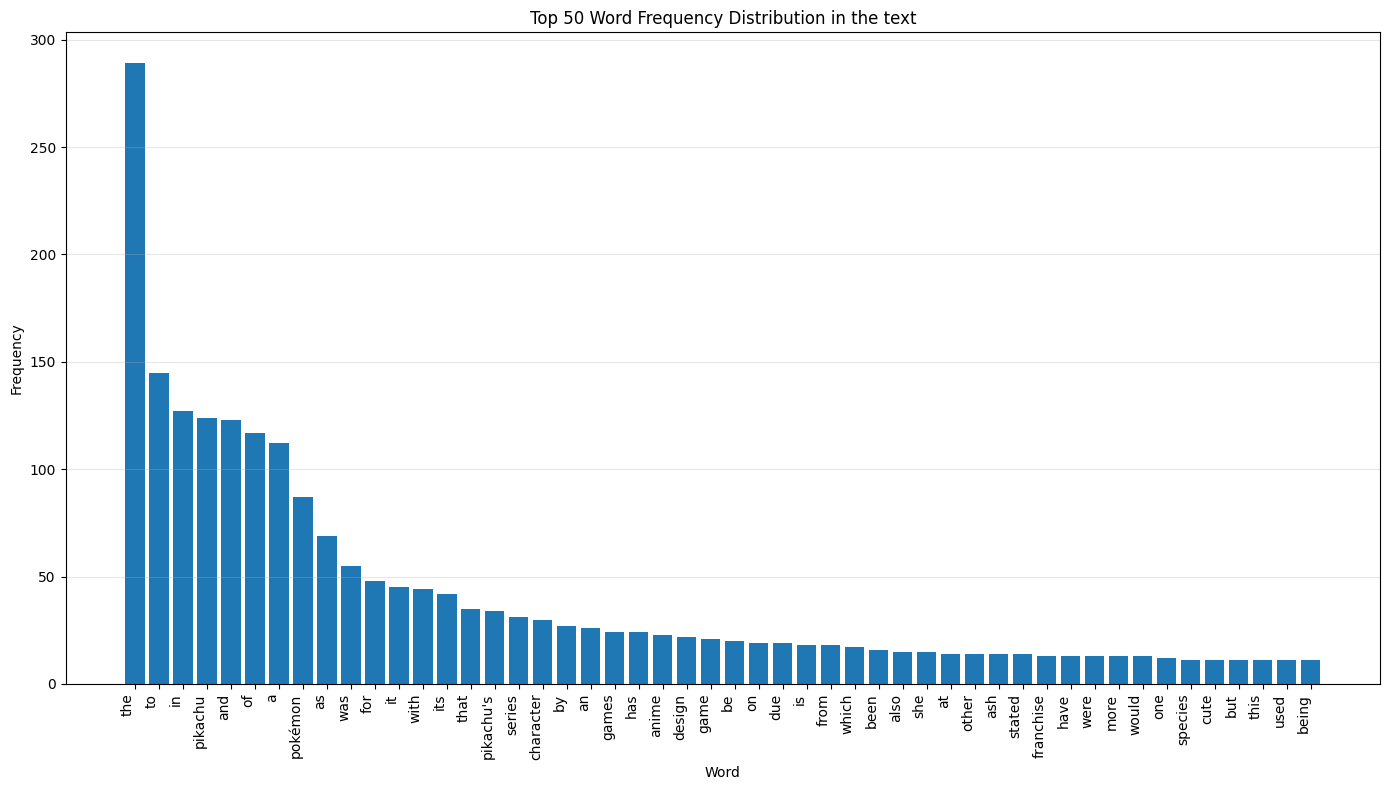

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
plt.bar(range(len(frequencies)), frequencies)
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.title('Top 50 Word Frequency Distribution in the text')
plt.xticks(range(len(words)), words, rotation=90, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

That's interesting! What can we conclude from the graph and the previous information?

The most used word's frequency is very high compared to the others, and while a few words are used more than the rest, a lot of words are only used a few times.

There are some words that are surely common in any text, such as 'the', 'to', or 'in'. But other words give us information about what the text is about, such as 'series', 'character', 'games', 'anime', etc.

We can also visualise the most used words using a world cloud, and for that we need the `wordcloud` library.

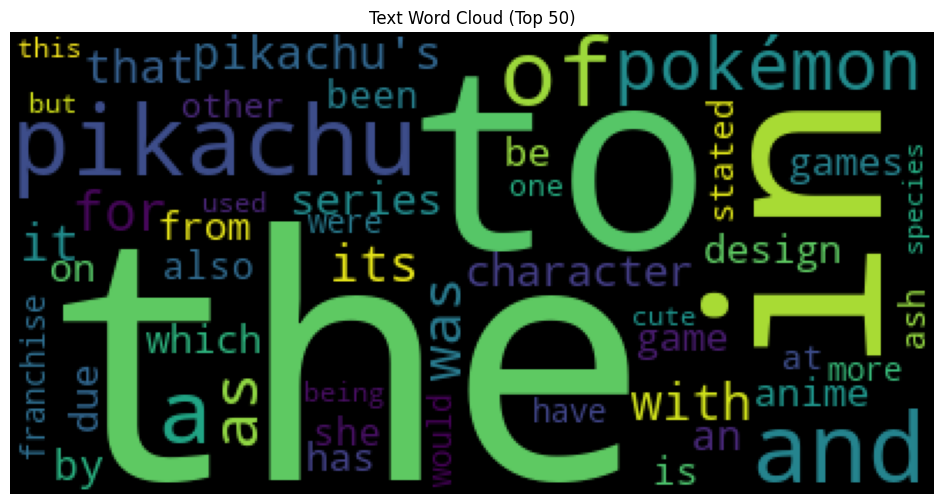

In [16]:
from wordcloud import WordCloud

# Use existing top words and frequencies
freq_map = dict(zip(words, frequencies))

wc = WordCloud()
wc.generate_from_frequencies(freq_map)

plt.figure(figsize=(12, 6))
plt.imshow(wc)
plt.axis("off")
plt.title("Text Word Cloud (Top 50)")
plt.show()

Which words with relevant meaning can you spot?

### Combination of words: n-grams

To understand the structure between text, however, we need to analyse how words are usually grouped. 
For that, we define  **n-grams**:
* A **bigram**, or 2-gram, is a group of two consecutive words.
* A **trigram**, or 3-gram, is a group of three consecutive words.
* An **n-gram** is a group of n consecutive words.

These groupings can help us understand the underlying structure of language within a text.

Let's analyse the text's bigrams: what are the most common sequences of two words?

In [17]:
# Create a list that has pairs of consecutive words
bigrams = list(zip(pikachu_word_list, pikachu_word_list[1:]))
# Create a counter for bigrams
bigram_counts = Counter(bigrams)

# Show the top 50 most common bigrams
print("Top 50 most common bigrams:")
for (bigram_word_1, bigram_word_2), bigram_word_count in bigram_counts.most_common(50):
    print(f"  ({bigram_word_1!r}, {bigram_word_2!r}): {bigram_word_count}")

Top 50 most common bigrams:
  ('in', 'the'): 41
  ('of', 'the'): 35
  ('for', 'the'): 21
  ('the', 'pokémon'): 20
  ('due', 'to'): 19
  ('as', 'the'): 15
  ('as', 'a'): 15
  ('the', 'anime'): 15
  ('the', 'character'): 13
  ('to', 'the'): 13
  ('has', 'been'): 11
  ('stated', 'that'): 11
  ('with', 'the'): 10
  ('to', 'be'): 10
  ('from', 'the'): 10
  ('the', 'series'): 10
  ('pikachu', 'has'): 9
  ('of', 'pikachu'): 9
  ('and', 'the'): 8
  ('it', 'was'): 8
  ('the', 'role'): 8
  ('one', 'of'): 8
  ('red', 'and'): 7
  ('pikachu', 'is'): 7
  ('the', 'most'): 7
  ('the', 'game'): 7
  ('such', 'as'): 7
  ('pikachu', 'as'): 7
  ('the', 'games'): 7
  ('pikachu', 'to'): 7
  ('at', 'the'): 6
  ('part', 'of'): 6
  ('of', 'a'): 6
  ('the', 'player'): 6
  ('other', 'pokémon'): 6
  ('the', 'franchise'): 6
  ('in', 'an'): 6
  ('to', 'have'): 6
  ('pikachu', 'and'): 6
  ('anime', 'series'): 6
  ('a', 'pokémon'): 5
  ('video', 'games'): 5
  ('games', 'pokémon'): 5
  ('the', 'design'): 5
  ('voiced',

We can visualize that in a histogram as well:

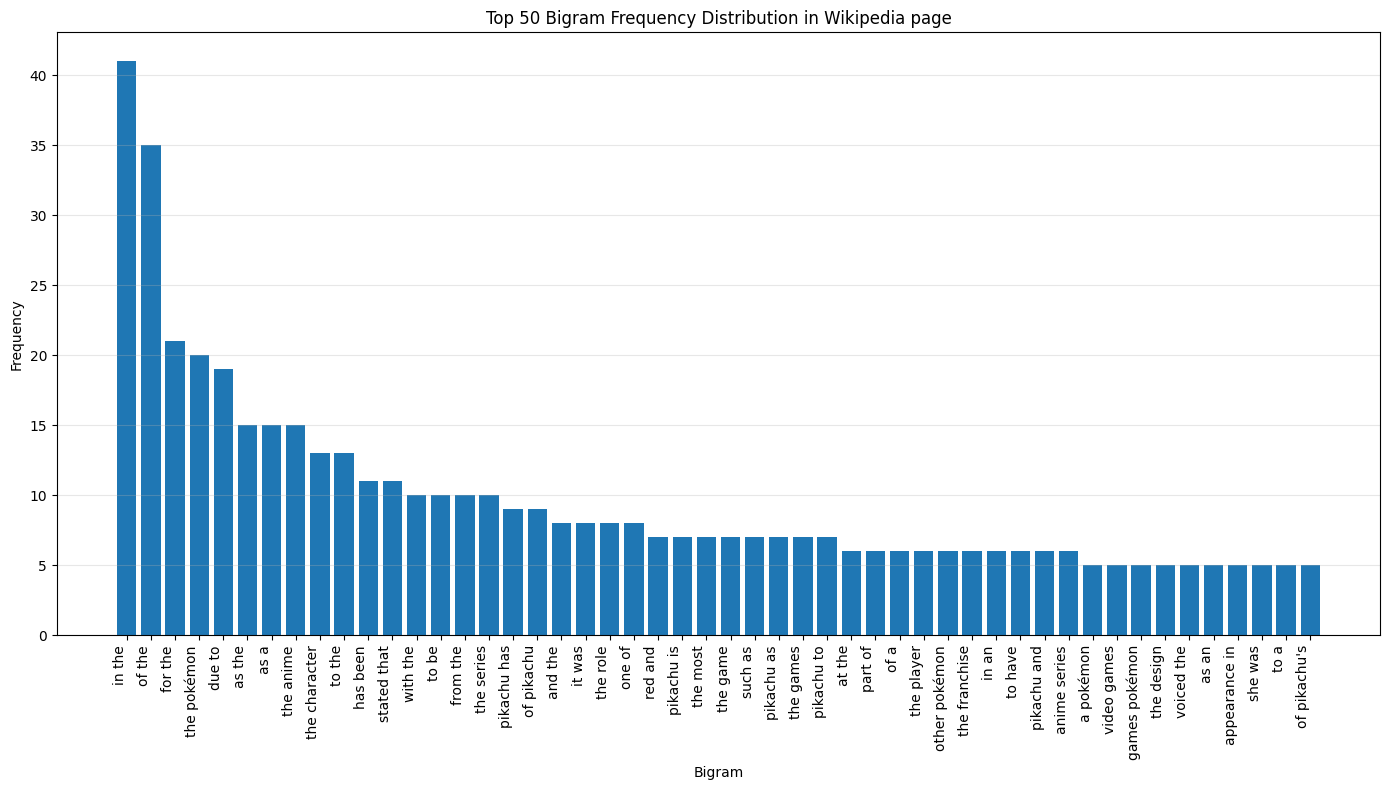

Most frequent bigram: 'in the' appears 41 times
Number of bigrams appearing only once: 2957


In [18]:
# Extract top 20 bigrams for visualization
top_n_bigrams = 50
top_bigrams = bigram_counts.most_common(top_n_bigrams)
bigram_labels = [f"{w1} {w2}" for (w1, w2), count in top_bigrams]
bigram_freqs = [count for (w1, w2), count in top_bigrams]

plt.figure(figsize=(14, 8))
plt.bar(range(len(bigram_freqs)), bigram_freqs)
plt.xlabel('Bigram')
plt.ylabel('Frequency')
plt.title(f'Top {top_n_bigrams} Bigram Frequency Distribution in Wikipedia page')
plt.xticks(range(len(bigram_labels)), bigram_labels, rotation=90, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Most frequent bigram: '{bigram_counts.most_common(1)[0][0][0]} {bigram_counts.most_common(1)[0][0][1]}' appears {bigram_counts.most_common(1)[0][1]} times")
print(f"Number of bigrams appearing only once: {sum(1 for count in bigram_counts.values() if count == 1)}")

We can see a similar frequency behaviour for bigrams, although the speed at which the frequency decreases seems to be lower for the most used 50 combinations.

Here some combination of words don't add a lot of information (words preceded by 'the', for example) but there are combination of words that represent concepts, such as 'anime series' or 'video games'.

We've analyzed both individual words and bigrams in the text. Now let's compare their frequency distributions as well as some statistics to understand how they differ in terms of frequency distributions.

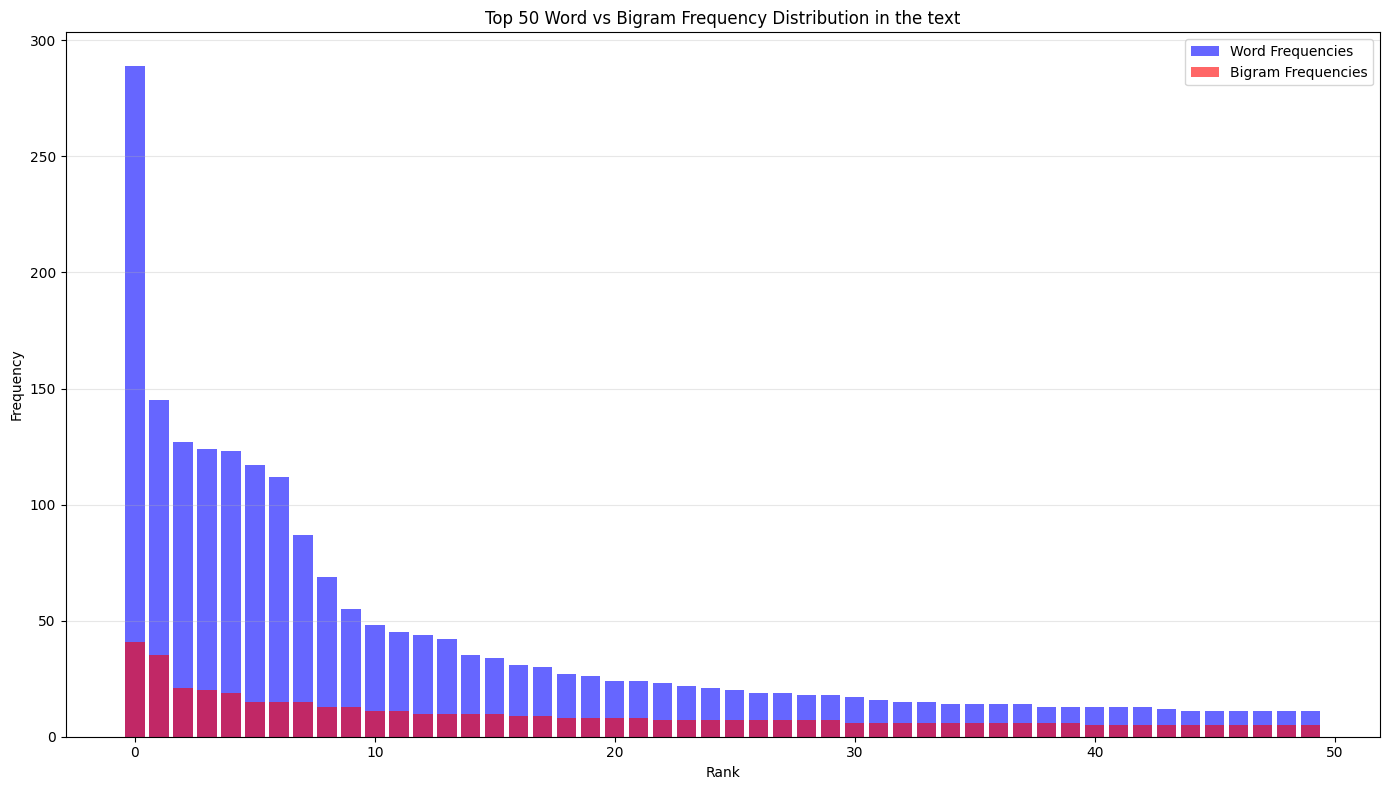

In [19]:
plt.figure(figsize=(14, 8))

# Plot both histograms with transparency
plt.bar(range(len(frequencies)), frequencies, alpha=0.6, color='blue', label='Word Frequencies')
plt.bar(range(len(bigram_freqs)), bigram_freqs, alpha=0.6, color='red', label='Bigram Frequencies')

plt.xlabel('Rank')
plt.ylabel('Frequency')
plt.title('Top 50 Word vs Bigram Frequency Distribution in the text')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
most_common_words, most_common_word_count = pikachu_word_counts.most_common(1)[0]
(most_common_word_1, most_common_word_2), most_common_bigram_count = bigram_counts.most_common(1)[0]

print("\n📊 Comparison:")
print(f"  Most common word: '{most_common_words}' ({most_common_word_count} times)")
print(f"  Most common bigram: '{most_common_word_1} {most_common_word_2}' ({most_common_bigram_count} times)")
print(f"  Total unique words: {len(pikachu_word_counts)}")
print(f"  Total unique bigrams: {len(bigram_counts)}")
print(f"  Bigram/Word ratio: {len(bigram_counts)/len(pikachu_word_counts):.2f}x more bigrams than words")


📊 Comparison:
  Most common word: 'the' (289 times)
  Most common bigram: 'in the' (41 times)
  Total unique words: 1370
  Total unique bigrams: 3390
  Bigram/Word ratio: 2.47x more bigrams than words


Looking at the statistics and the two frequency histograms reveals interesting patterns:

**Vocabulary Size**: There are many more unique bigrams than unique words. This is because there are exponentially more ways to combine words into pairs than there are individual words.

**Frequency**: The most common word appears far more frequently than the most common bigram. This makes sense, since individual words like "the" or "of" can be used in many different contexts, while specific two-word combinations are more restricted.

**Histogram Shape**: Both histograms follow a similar pattern: Both curves drop steeply at first, then gradually level off. This means a few words/bigrams dominate, while most appear relatively rarely (which shows as a "long tail").

> Challenge:
> What happens with other Wikipedia pages? Can you guess what the text is about based on this information?

### **Section 1. Summary**

We have successfully analysed a whole book!

We have new insights on:
* The **vocabulary size**, or how many different words there are in the text
* The text's **most used words**, and their **frequencies**
* The definition of an **n-gram**, or a squence of n words
* How the **frequencies of words** and the **frequencies of bigrams** compare
* How all these concepts can help us gain understanding of a text

---

# **2.** Analysing Audio 🎵

During the previous notebook we learnt about the MIDI protocol. We successfully encoded a melody into numbers, and were able to decode that series of numbers into the original melody (and listen to it!).

However, you might thinking that doesn't sound like the music you usually listen to, and you would be right. Most of the times we listen to music we are reproducing an audio file. How does that work? Well, the music stored in a digital device is a **digital audio signal**.

## 1.i. Digital audio signals

### Waveforms

In essence, sound is simply air vibrating. An audio signal, then, **represents the fluctuation in air pressure caused by the vibration as a function of time**.

We can graphically represent the change in air pressure caused by a vibration at a certain point in time using a pressure-time plot. This is more commonly known as a **waveform**, and you've probably seen one before:

<img src="https://media.wired.com/photos/65e8385a7e55097b1dfa6ac1/master/w_1600%2Cc_limit/iStock-500703366.jpg" width="400px"/>

Let's see the waveform corresponding to an audio file. We'll use the `librosa` library to do this.

In [21]:
import librosa
import IPython.display as ipd

# Load example audio file
filename = librosa.ex('trumpet')
y_trumpet, sr_trumpet = librosa.load(filename)
# play the audio
ipd.Audio(y_trumpet, rate=sr_trumpet)

We can produce a waveform for an audio signal directly in Python by plotting the signal information.

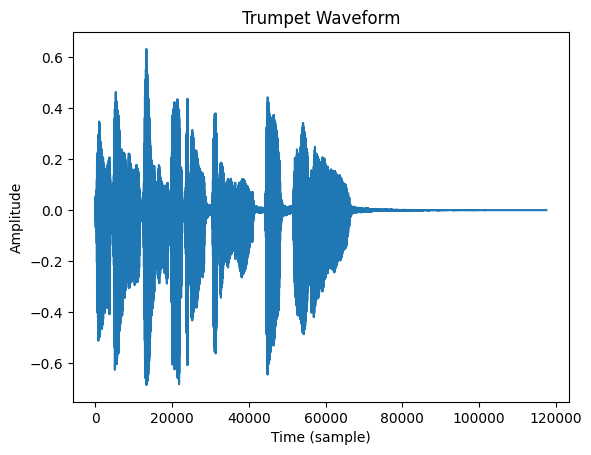

In [22]:
plt.plot(y_trumpet)
plt.gca().set(xlabel="Time (sample)", ylabel="Amplitude")
plt.title("Trumpet Waveform")
plt.show()

As you can see, the moments of silence have an amplitude of zero, while the maximum peaks in the plot correspond to the moments where we hear the sound is louder.

You might be wondering, though, how is information represented here?

#### Sample Rate 🔢


When working with digital audio the information is once more a sequence of numbers. In this case, we have a new value for the waveform at regular intervals of time. Each one of these data points is called a **sample**!

<img src="https://jvbalen.github.io/figs/rick.gif" alt="Zooming into an audio file" width="500px"/>

Let's check the values of the first 10 samples of the audio file:

In [23]:
print(y_trumpet[:10])

[-1.4068246e-03 -4.4607770e-04 -4.1098156e-04  9.9922603e-05
  4.3147978e-05 -1.7485370e-04 -3.6783644e-04  1.4553108e-04
  5.0557696e-04  1.4929977e-03]


How often we have a new sample is determined by the **sample rate** (sometimes abbreviated as `sr`). The **sample rate** is measured in Hertz (Hz), and represents how many samples we have in one second. It is also the inverse of the time interval between two consecutive samples.

<img src="https://www.hollyland.com/wp-content/uploads/2023/11/image-563.png" alt="Comparison between low and high sample rates" width="500px"/>


Let's print out the sample rate of our audio:

In [24]:
print(sr_trumpet)

22050


This means the audio file has 22050 samples per second, and that samples are 1/22050 seconds apart.

Standard sample rates you might encounter include:
- 44100 Hz (44.1 kHz): the standard sample rate for **CD-quality** audio
- 48000 Hz (48 kHz): the standard sample rate for **DVD-quality** audio.
- 96000 Hz (96 kHz): double the rate of 48 kHz, common in **high-resolution audio** but rarer in everyday listening.
- 22050 Hz: half the rate of CD-quality audio. Common in machine learning contexts.

Note that humans cannot easily hear the difference between 48 and 44.1 kHz sampling rates. One benefit of the lower value is that audio encoded as 44.1 kHz usually has a **smaller file size**, simply because it has fewer samples per second.

## **1.ii** Time Domain Audio Features

Now that we know how audio signals are represented it's time to ask: what kind of statistical information can we get from an audio signal? We call these measurable characteristics of sound **audio features**, and we'll cover some interesting examples ahead.

### Root Mean Square (RMS)
The Root Mean Square (RMS) feature measures the average power or loudness of a signal over time. 

It can be calculated as


$${RMS} = \sqrt{\frac{1}{N}\sum_{n=1}^{N} x_n^2}$$

where

$x_n$ is the $n$-th sample of the audio signal

$N$ is the total number of samples in the signal

Let's calculate that feature using the `librosa` library and visualise it in a plot:

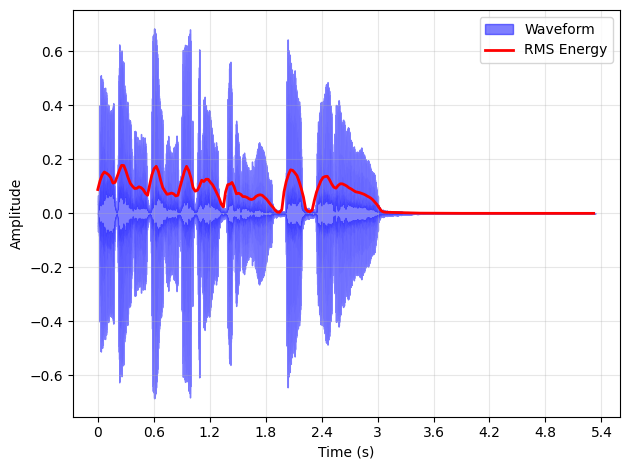

In [25]:
# Calculate RMS energy
rms = librosa.feature.rms(y=y_trumpet, frame_length=2048, hop_length=512)

# Plot waveform using librosa.display
librosa.display.waveshow(y_trumpet, sr=sr_trumpet, alpha=0.5, label='Waveform', color='blue')

# Plot RMS energy overlay
frames = range(len(rms[0]))
times_rms = librosa.frames_to_time(frames, sr=sr_trumpet, hop_length=512)
plt.plot(times_rms, rms[0], color='red', linewidth=2, label='RMS Energy')

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Listen to the audio while looking at the graph: what do you notice?

In [26]:
ipd.Audio(y_trumpet, rate=sr_trumpet)

We can clearly see that the RMS value follows the energy of the signal: it is larger when the volume is higher, and it is zero when the signal is quiet. This gives us an idea of how loud the signal is, and could be a great feature to consider if we want to detect when notes are being played (what we call an **onset detection** task).

#### Zero Crossing Rate (ZCR)

Another interesting audio feature is the Zero Crossing Rate, which, as its name says, measures how many times the signal crosses zero (that is, changes sign!) in a given time frame.

It can be mathematically expressed as

$${ZCR} = \frac{1}{(N-1)}\sum_{n=1}^{N-1} \left| \operatorname{sgn}(x_{n+1}) - \operatorname{sgn}(x_n) \right|$$

where
$$
\operatorname{sgn}(x) =
\begin{cases}
+1, & x > 0, \\
0,  & x = 0, \\
-1, & x < 0.
\end{cases}
$$

Let's see what the Zero Crossing Rate looks like for the same signal:

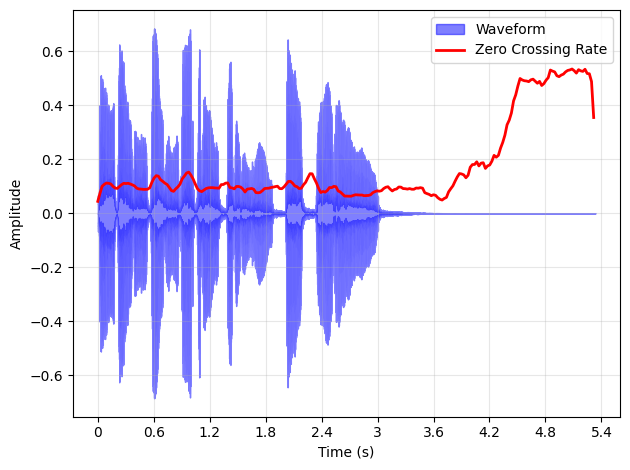

In [27]:
# Calculate Zero Crossing Rate
zcr = librosa.feature.zero_crossing_rate(y=y_trumpet, frame_length=2048, hop_length=512)

# Plot waveform using librosa.display
librosa.display.waveshow(y_trumpet, sr=sr_trumpet, alpha=0.5, label='Waveform', color='blue')

# Plot ZCR overlay
frames = range(len(zcr[0]))
times_zcr = librosa.frames_to_time(frames, sr=sr_trumpet, hop_length=512)
plt.plot(times_zcr, zcr[0], color='red', linewidth=2, label='Zero Crossing Rate')

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Wait, why is the value so high if the signal is silent? Let's inspect the final samples of the signal.

Text(0, 0.5, 'Amplitude')

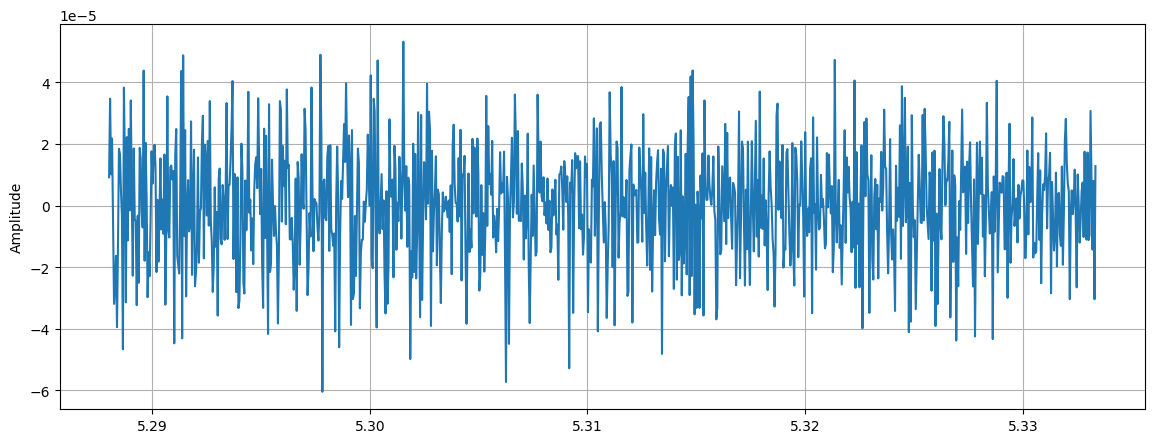

In [28]:
import numpy as np

n_samples = len(y_trumpet)
times_trumpet = np.arange(n_samples) / sr_trumpet

plt.figure(figsize=(14, 5))
plt.plot(times_trumpet[-1000:], y_trumpet[-1000:])
plt.grid()
plt.ylabel("Amplitude")

Even though the signal's amplitude is very low, the signal has a lot of zero crossings!

This problem can be solved by adding a small integer to the signal when calculating the zero crossing rate, as follows:

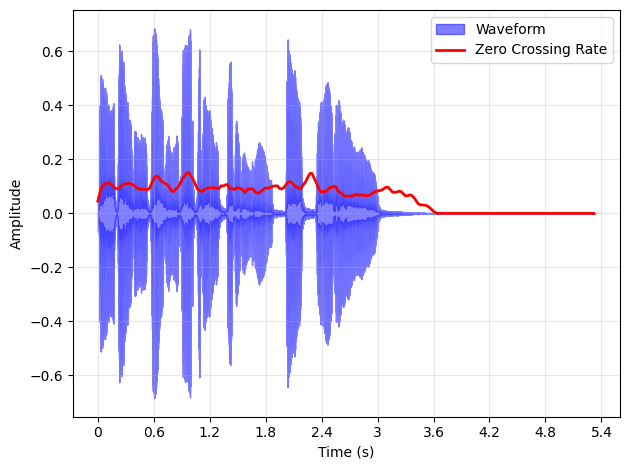

In [29]:
# Calculate Zero Crossing Rate
zcr = librosa.feature.zero_crossing_rate(y=y_trumpet + 0.001, frame_length=2048, hop_length=512)

# Plot waveform using librosa.display
librosa.display.waveshow(y_trumpet, sr=sr_trumpet, alpha=0.5, label='Waveform', color='blue')

# Plot ZCR overlay
frames = range(len(zcr[0]))
times_zcr = librosa.frames_to_time(frames, sr=sr_trumpet, hop_length=512)
plt.plot(times_zcr, zcr[0], color='red', linewidth=2, label='Zero Crossing Rate')

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Listen again while looking at the graph: what is this feature related to?

In [30]:
ipd.Audio(y_trumpet, rate=sr_trumpet)

While it might not be evident at first glance, this feature is highly related to the frequency of the signal (the higher the frequency, the more zero crossings we have!). Therefore, it is a feature often used to **analyse pitch**. In this case, we can notice the shape of the graph follows the melody that's being played.

## 1.iii. Frequency Domain: Using Spectrograms 📢

While the above features are informative, we're not taking advantage of all the information we have. Another useful way of representing audio is using a **spectrogram**.

We can think of spectrograms as a 3D map of the audio signal, showing the amount of energy (coded in height values), for each:
* Frequency value (in Hertz), which is related to pitch: the lowest the frequency, the lowest the sound is pitched.
* Moment of time (in seconds or milliseconds)


<img src="https://www.researchgate.net/publication/347874331/figure/fig3/AS:974591413477377@1609372108329/Working-of-a-Spectrogram-24-3D-Visualization-of-a-Spectrogram.jpg" width="700px"/>


For practical reasons, we usually represent these maps in 2D coding the height as colour:

<img src="https://upload.wikimedia.org/wikipedia/commons/c/c5/Spectrogram-19thC.png" width="700px"/>

* If we follow horizontal axis in the right direction, the time is passing
* In the vertical axis we can explore the value for different frequencies
* The colour represents the energy: the brighter a region is, the more energy we have for that frequency at that time!

Now let's look at the spectrogram of our audio file!

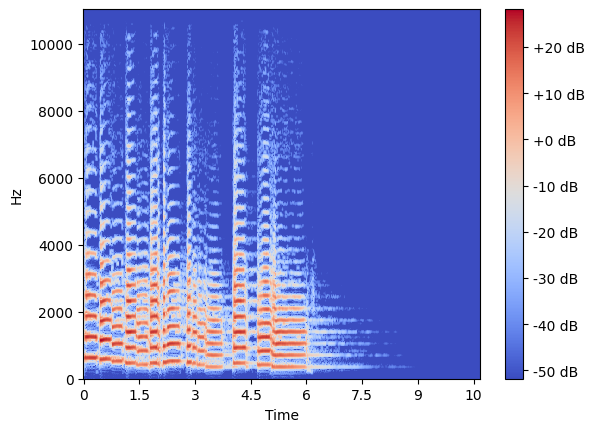

In [31]:
# Don't worry about this code block now! You might want to learn about STFTs later on.
X_stft_trumpet = librosa.stft(y_trumpet, win_length=512, hop_length=256)
spect_trumpet = librosa.amplitude_to_db(np.abs(X_stft_trumpet))
# show spectrogram
librosa.display.specshow(spect_trumpet, sr=sr_trumpet, x_axis="time", y_axis="linear")
# show colorbar
plt.colorbar(format="%+2.0f dB")
plt.show()

Now listen to the audio again while looking at the spectrogram, let's try to interpret what is happening. Try to focus on the bright lines that evolve in the horizontal direction.

In [32]:
ipd.Audio(y_trumpet, rate=sr_trumpet)

Those bright lines follow the movement of the melody being played! The bottom one corresponds to the **fundamental frequency** of each note, and once we map the frequency to the world of notes, it will give the note its name. The very similar contours that appear periodically in higher frequencies are called **harmonics**, and their strength is a very important piece of information that allows us to distinguish between instruments playing the same notes. For instance, the higher the strength of the upper harmonics, the brighter the sound will be.

As it is, the spectrogram is already a very useful representation. But, can we also process it to get relevant features?

## 1.iv. Spectrotemporal Audio Features 🎼

Now we'll explore some **audio features** that are based on the spectrogram's information, therefore, we can say they are **spectrotemporal**, since they analyse the evolution of frequency domain information over time.

### Spectral Centroid ⭕

You might not have heard the term spectral centroid before, but the idea behind it is pretty simple. For each *column* in the spectrogram (each moment in time), we find the average frequency where most of the sound's energy is concentrated.

In other words, let $x^j$ be the vector corresponding with column $j$ of a spectrogram. We then calculate the spectral centroid $SC$ at $j$ as:

$$
SC_j = \frac{1}{n} \sum_{i=1}^{n} x_i^j
$$

where $n$ is the number of frequency bins in that column.

This gives the centroid for a single moment. Since a sound changes over time, we can calculate the centroid for **every column** in the spectrogram. This produces a sequence of values showing how the "center of energy" moves through the frequencies as the sound plays:

$$
\mathbf{SC} =
\begin{bmatrix}
SC_1 \\
SC_2 \\
\vdots \\
SC_m
\end{bmatrix}
=
\begin{bmatrix}
\frac{1}{n} \sum_{i=1}^{n} x_i^1 \\[1em]
\frac{1}{n} \sum_{i=1}^{n} x_i^2 \\[0.5em]
\vdots \\[0.5em]
\frac{1}{n} \sum_{i=1}^{n} x_i^m
\end{bmatrix}
\in \mathbb{R}^m
$$

where $m$ is the total number of columns in the spectrogram.

The vector $\mathbf{SC}$ is one-dimensional and varies over time. You can think of it as a simple line that tracks whether the sound is mostly low-pitched or high-pitched at each moment. It provides a compact way to summarize the "brightness" of a sound without examining the entire spectrogram.

Let's plot the spectral centroid of our signal.

c:\Users\jimea\OneDrive\Documents\QMUL\Work\epsrc-ai-pipeline\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


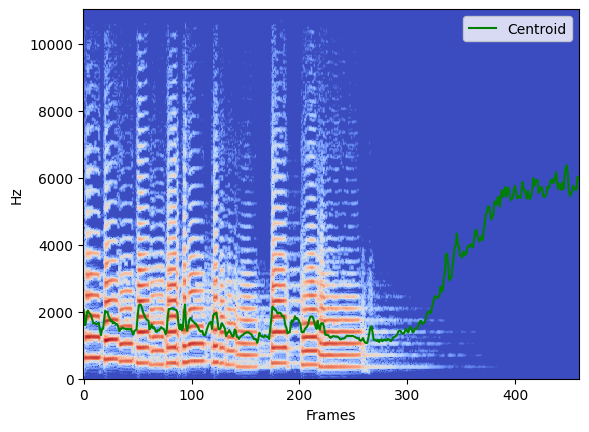

In [33]:
cent_trumpet = librosa.feature.spectral_centroid(S=np.abs(X_stft_trumpet), sr=sr_trumpet, win_length=512, hop_length=256)
librosa.display.specshow(spect_trumpet, sr=sr_trumpet, x_axis="frames", y_axis="linear")
plt.plot(cent_trumpet[0], label="Centroid", color="green")
plt.legend()
plt.show()

Again, issues arise when the signal is close to zero. We shoul probably only consider the part of the signal where there's audio for the rest of the analysis.

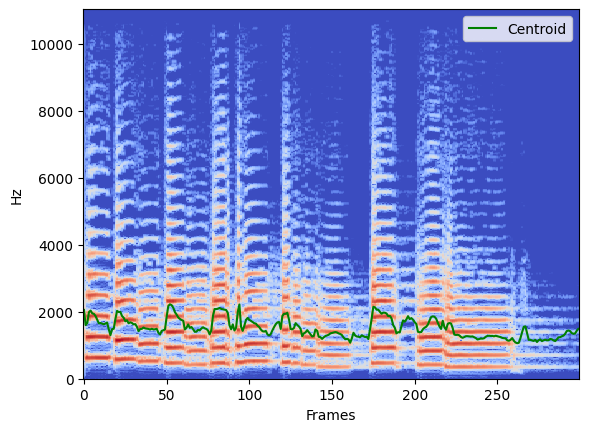

In [34]:
cent_trumpet = librosa.feature.spectral_centroid(S=np.abs(X_stft_trumpet), sr=sr_trumpet, win_length=512, hop_length=256)
librosa.display.specshow(spect_trumpet[:, :300], sr=sr_trumpet, x_axis="frames", y_axis="linear")
plt.plot(cent_trumpet[0, :300], label="Centroid", color="green")
plt.legend()
plt.show()

Can we hear the brightness changes shown in the graph above?

In [35]:
ipd.Audio(y_trumpet, rate=sr_trumpet)

The usefulness of this feature is more evident if we compare two different instruments. How about a piano?

In [36]:
filename = librosa.ex('pistachio')
y_piano, sr_piano = librosa.load(filename)
# play the first 5 seconds of the piano audio
ipd.Audio(y_piano[:int(5 * sr_piano)], rate=sr_piano)

What does the spectrogram look like for this signal?

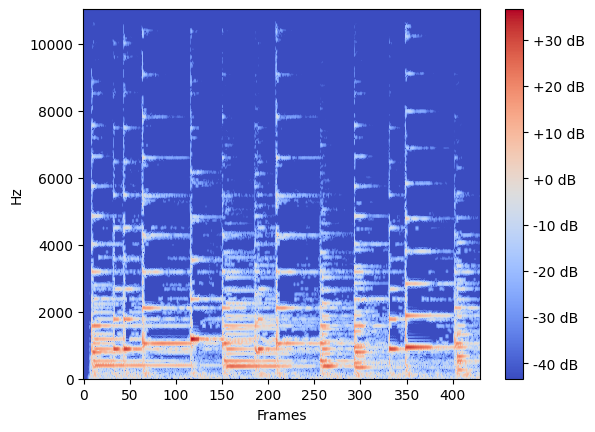

In [37]:
X_stft_piano = librosa.stft(y_piano, win_length=512, hop_length=256)
spect_piano = librosa.amplitude_to_db(np.abs(X_stft_piano))

# Calculate number of frames for 5 seconds
frames_5s = int(5 * sr_piano / 256)

librosa.display.specshow(spect_piano[:, :frames_5s], sr=sr_piano, x_axis="frames", y_axis="linear")
plt.colorbar(format="%+2.0f dB")
plt.show()

We can already see the distribution of energy of the harmonics is very different from what we saw in the trumpet! Therefore, the values for the spectral centroid (which act as a summary) must also be very different.

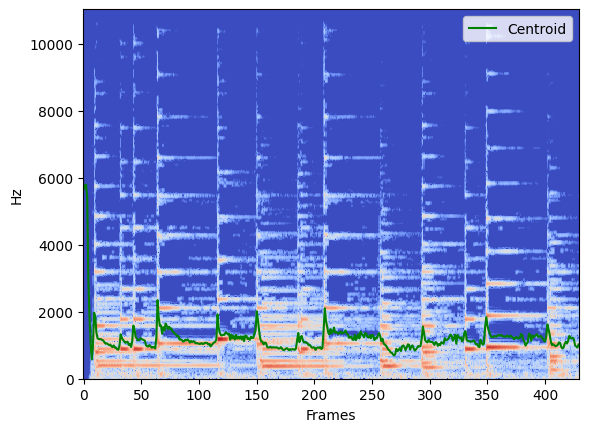

In [38]:
cent_piano = librosa.feature.spectral_centroid(S=np.abs(X_stft_piano), sr=sr_piano, win_length=512, hop_length=256)
librosa.display.specshow(spect_piano[:, :frames_5s], sr=sr_piano, x_axis="frames", y_axis="linear")
plt.plot(cent_piano[0, :frames_5s], label="Centroid", color="green")
plt.legend()
plt.show()

Looking at the graph while listening to the audio, can you tell when the pianist is playing chords and when there are notes of the melody played?

In [39]:
ipd.Audio(y_piano[:int(5 * sr_piano)], rate=sr_piano)

To help us compare the two recordings, we can also rely on statistics. What's the mean of the spectral centroid for each signal? What about the standard deviation?

In [40]:
# skipping the first 10 results, as they are very noisy
print(f"Mean spectral centroid for piano: {np.mean(cent_piano[0,10:]):.2f} Hz")
print(f"Standard deviation of spectral centroid for piano: {np.std(cent_piano[0,10:]):.2f} Hz")

# skipping the silence in the end
print(f"Mean spectral centroid for trumpet: {np.mean(cent_trumpet[0,:300]):.2f} Hz")
print(f"Standard deviation of spectral centroid for trumpet: {np.std(cent_trumpet[0,:300]):.2f} Hz")

Mean spectral centroid for piano: 986.89 Hz
Standard deviation of spectral centroid for piano: 248.99 Hz
Mean spectral centroid for trumpet: 1510.38 Hz
Standard deviation of spectral centroid for trumpet: 278.70 Hz


Looking at both plots and the mean values for their centroids, we can conclude:
* the sound of the trumpet is generally brighter than the piano
* the piano signal presents more variation in how bright the sound is (the notes of the melody are clearly brighter than the chords in this case!).

This could be very useful if we wanted to identify which instrument is playing.

#### Spectral Bandwidth 🔀

Just as our **spectral centroid** is equivalent to the *average frequency* for every column in our spectrogram, we can also consider the **standard deviation** of every column. We call this feature the **spectral bandwidth**.

Let $x^j$ be the vector corresponding to column $j$ of the spectrogram. The spectral bandwidth at time $j$ is:

$$
SB_j = \sqrt{\frac{1}{n} \sum_{i=1}^{n} \left(x_i^j - SC_j\right)^2}
$$

where $SC_j$ is the spectral centroid for column $j$ and $n$ is the number of frequency bins.

> Recall that $SC_j$ is simply the mean of $x^j$

By computing this for **every column**, we get a sequence of values showing how the frequency spread changes over time:

$$
\mathbf{SB} =
\begin{bmatrix}
SB_1 \\
SB_2 \\
\vdots \\
SB_m
\end{bmatrix}
\in \mathbb{R}^m
$$

The vector $\mathbf{SB}$ is also one-dimensional. It tells us whether the sound is concentrated around a narrow range of frequencies or spread out over a wide range at each moment.

To better understand this feature, let's use some new examples.

The first is a robin bird singing.

In [41]:
filename = librosa.ex('robin')
y_robin, sr_robin = librosa.load(filename)
ipd.Audio(y_robin, rate=sr_robin)

The second is a vibraphone, piano, and bass combo. Since it's a long piece, let's only listen to 5 seconds, from second 30 to second 35.

In [42]:
filename = librosa.ex('vibeace')
y_vibeace, sr_vibeace = librosa.load(filename)
ipd.Audio(y_vibeace[30 * sr_vibeace: 35 * sr_vibeace], rate=sr_vibeace)

Knowing what the spectral bandwith represents, how do you think the values for these two signals will compare? Which one should have a greater spectral bandwidth?

Let's check if your guess is right!

Let's start with the robin:

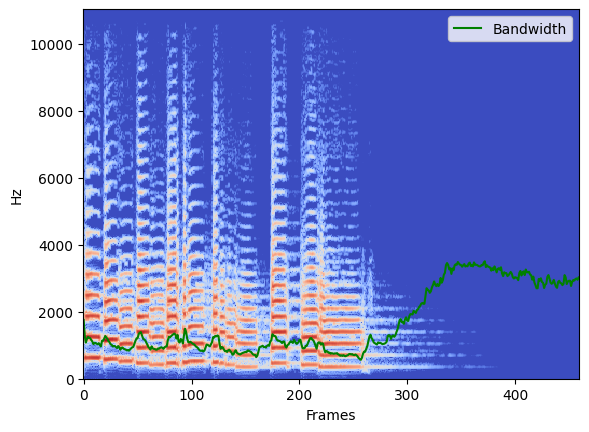

In [43]:
bw_trumpet = librosa.feature.spectral_bandwidth(S=np.abs(X_stft_trumpet), sr=sr_trumpet, win_length=512, hop_length=256)
librosa.display.specshow(spect_trumpet, sr=sr_trumpet, x_axis="frames", y_axis="linear")
plt.plot(bw_trumpet[0], label="Bandwidth", color="green")
plt.legend()
plt.show()

Now let's analyse it for 5 seconds in the middle of the `vibeace` example.

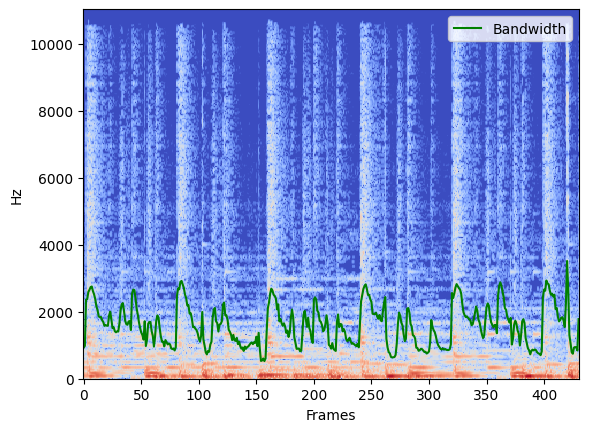

In [44]:
X_stft_vibeace = librosa.stft(y_vibeace, win_length=512, hop_length=256)
spect_vibeace = librosa.amplitude_to_db(np.abs(X_stft_vibeace))

# Calculate number of frames for 30 seconds
frames_30s = int(30 * sr_vibeace / 256)
frames_35s = int(35 * sr_vibeace / 256)

bw_vibeace = librosa.feature.spectral_bandwidth(S=np.abs(X_stft_vibeace), sr=sr_vibeace, win_length=512, hop_length=256)
librosa.display.specshow(spect_vibeace[:, frames_30s:frames_35s], sr=sr_vibeace, x_axis="frames", y_axis="linear")
plt.plot(bw_vibeace[0][frames_30s:frames_35s], label="Bandwidth", color="green")
plt.legend()
plt.show()

In [46]:
print(f"Mean spectral bandwidth for robin: {np.mean(bw_trumpet):.2f} Hz")
print(f"Standard deviation of spectral bandwidth for robin: {np.std(bw_trumpet):.2f} Hz")
print(f"Mean spectral bandwidth for vibraphone, piano and bass: {np.mean(bw_vibeace[0, frames_30s:frames_35s]):.2f} Hz")
print(f"Standard deviation of spectral bandwidth for vibraphone, piano and bass: {np.std(bw_vibeace[0, frames_30s:frames_35s]):.2f} Hz")

Mean spectral bandwidth for robin: 1694.72 Hz
Standard deviation of spectral bandwidth for robin: 981.99 Hz
Mean spectral bandwidth for vibraphone, piano and bass: 1589.75 Hz
Standard deviation of spectral bandwidth for vibraphone, piano and bass: 607.24 Hz


CONCLUSION

#### More Features 📂

There are **many more features** that we could extract from a spectrogram or waveform. From your own knowledge of mathematics and statistics, *can you think of any other features we might be able to extract?*

For more information on the features that can be extracted from an audio signal with `librosa`, check out [the documentation.](https://librosa.org/doc/latest/feature.html)

### **2. Summary**

* Digital audio signals consist of ordered **samples**. The **sample rate** of the signal indicates how many samples the signal presents at each second.
* Audio signals can be visualized by plotting their **waveform**.
* We can analyse the frequency content of the signal over time by looking at its **spectrogram**.
* By processing the signal's waveform, we can obtain **temporal features** such as the signal's **Root Mean Square (RMS)** values and **Zero Crossings Rate (ZCR)**.
* By processing the signal's spectrogram, we can obtain **spectrotemporal features** such as **spectral centroid** and **spectral bandwidth**.

## 3. Analysing Images 🖼

As we learnt in the previous notebook, images are in fact a grid of pixels.

Let's load an image in Python see that in action. We'll use the `skimage` library.


In [ ]:
import skimage

astronaut = skimage.data.astronaut()
print(astronaut.shape)

(512, 512, 3)


If we inspect the image, we can see that we have a 3 dimensional array.
- The first dimension (512) shows the number of rows, which correspond to the image's height in pixels.
- The second dimension (512) represents the number of columns, or the image's width in pixels.
- The third dimension (3) corresponds to the colour channels: Red, Green, and Blue (RGB).

So this image is a **512 x 512 pixel color image**, where each pixel has three values representing the intensity of red, green, and blue. Let's show the image:


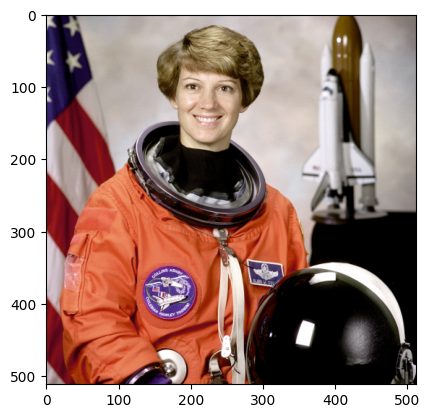

In [ ]:
plt.imshow(astronaut)
plt.show()

(427, 640, 3)


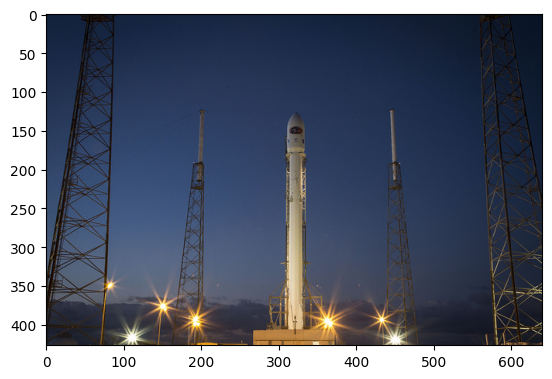

In [ ]:
rocket = skimage.data.rocket()
print(rocket.shape)
plt.imshow(rocket)
plt.show()

### Feature Extraction

When we were working with audio signals, it often made sense to extract features as **one-dimensional sequences**, where each point corresponded to a frame in a spectrogram. This worked because sound changes over time, and we could describe how certain properties - like brightness or pitch - evolved from moment to moment.

When working with images, this idea **doesn't quite apply** in the same way. Unlike audio, an image has no concept of time - it's a single snapshot rather than a sequence of events. One column of pixels doesn't "occur" before or after another; instead, every pixel exists simultaneously in two spatial dimensions.


Because of this, we usually extract **spatial features** from images instead of temporal ones. These features describe what the image looks like in terms of **colour, texture, edges, or shapes,** rather than how something changes over time.


#### Grayscale ⬛

Notice how our colour image is three-dimensional: we have separate values for every pixel showing the amount of red, green, and blue within the image.

Sometimes in machine learning, we may not need to pass this information to the model. For instance, in object detection, we might only be interested in the *shapes and contours* of the objects in the image, and *not their colour*. Instead, we can convert our image to grayscale (or black-and-white).

We can use `skimage` to do this for us:

In [ ]:
astronaut_gray = skimage.color.rgb2gray(astronaut)
print(astronaut_gray.shape)

(512, 512)


Notice how we've lost the third dimension of our array (sometimes called the *"channel dimension"*). Now we have a two-dimensional image, reprented as a 512 x 512 grid. Every value in this grid corresponds to the grayscale value of that pixel. Values of 0 are black; as this number increases, *more and more white* is added.

Let's show the transformed image:

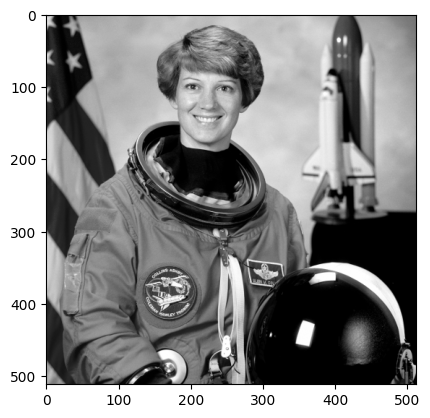

In [ ]:
plt.imshow(astronaut_gray, cmap=plt.cm.gray)
plt.show()

(427, 640)


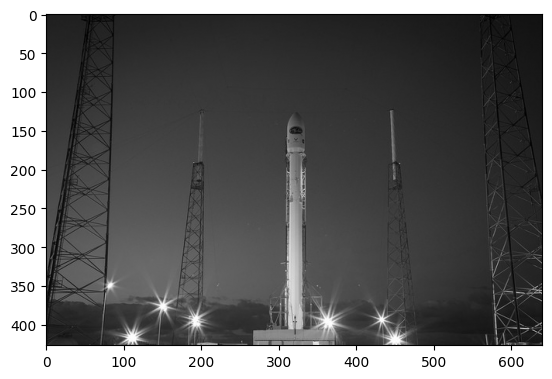

In [ ]:
rocket_gray = skimage.color.rgb2gray(rocket)
print(rocket_gray.shape)
plt.imshow(rocket_gray, cmap=plt.cm.gray)
plt.show()

### Pixel Intensity Histogram

WHAT IT IS

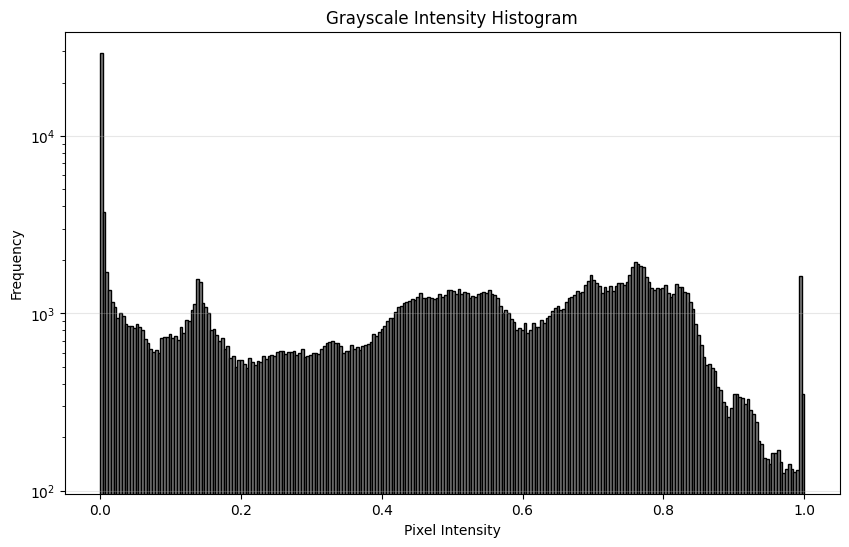

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(astronaut_gray.flatten(), bins=256, range=(0, 1), color='gray', edgecolor='black')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.title('Grayscale Intensity Histogram')
plt.grid(axis='y', alpha=0.3)
plt.yscale('log')
plt.show()

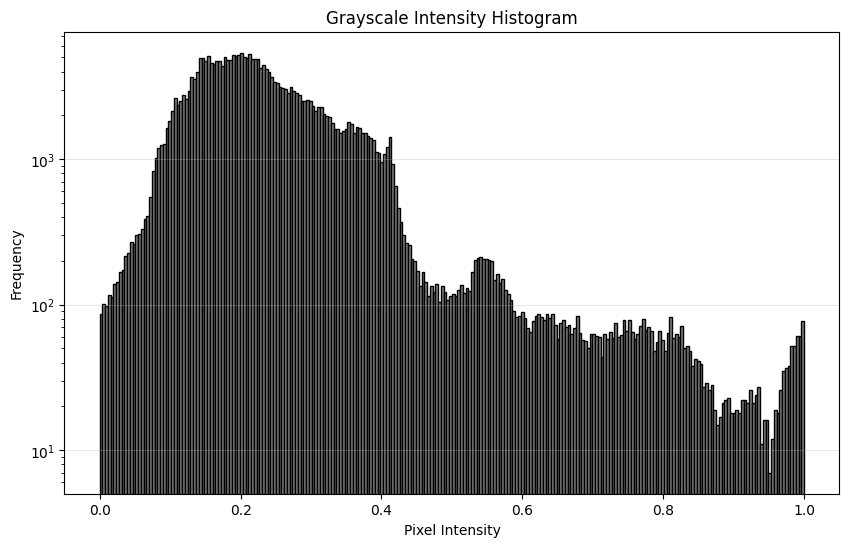

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(rocket_gray.flatten(), bins=256, range=(0, 1), color='gray', edgecolor='black')
plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.title('Grayscale Intensity Histogram')
plt.grid(axis='y', alpha=0.3)
plt.yscale('log')
plt.show()

COMPARISONS

#### Colour Histogram

HEY! IT'S IN COLOUR

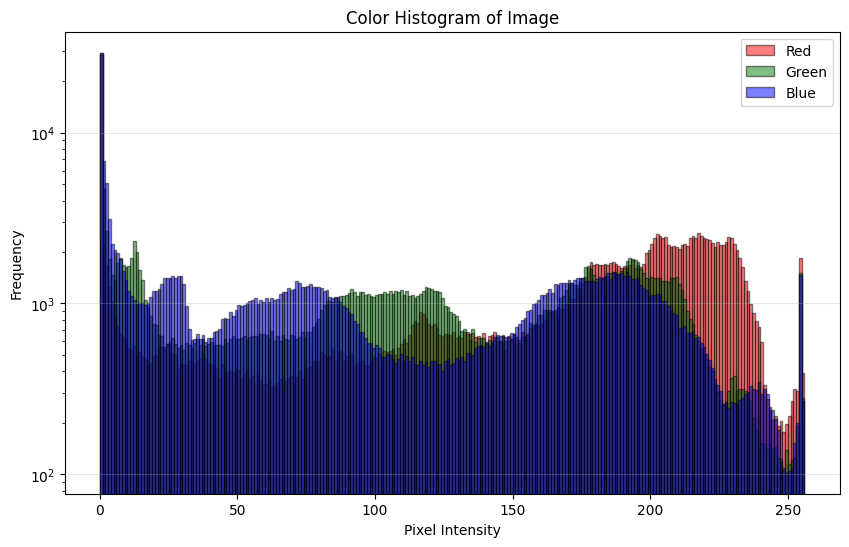

In [ ]:
plt.figure(figsize=(10, 6))

# Extract each color channel
red = astronaut[:, :, 0].flatten()
green = astronaut[:, :, 1].flatten()
blue = astronaut[:, :, 2].flatten()

# Plot histograms for each channel
plt.hist(red, bins=256, range=(0, 256), alpha=0.5, label='Red', color='red', edgecolor='black')
plt.hist(green, bins=256, range=(0, 256), alpha=0.5, label='Green', color='green', edgecolor='black')
plt.hist(blue, bins=256, range=(0, 256), alpha=0.5, label='Blue', color='blue', edgecolor='black')

plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.title('Color Histogram of Image')
plt.legend()
plt.yscale('log')
plt.grid(axis='y', alpha=0.3)
plt.show()

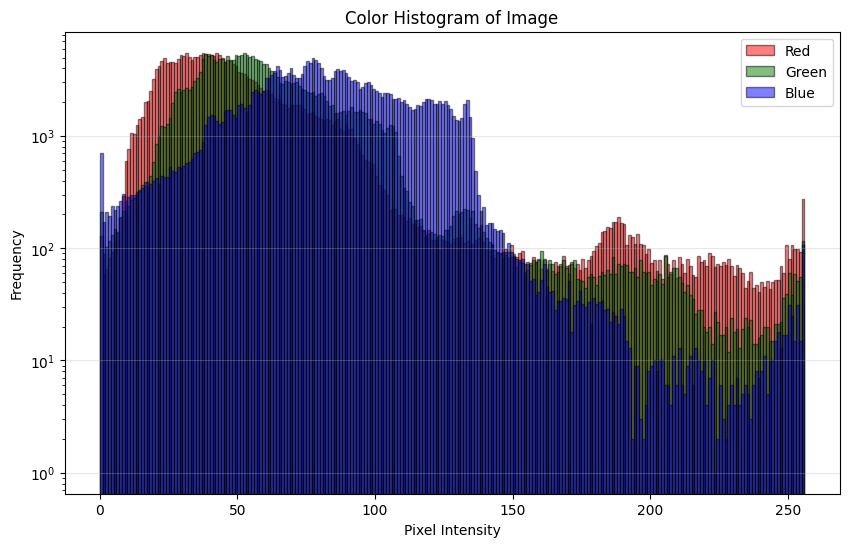

In [ ]:
plt.figure(figsize=(10, 6))

# Extract each color channel
red = rocket[:, :, 0].flatten()
green = rocket[:, :, 1].flatten()
blue = rocket[:, :, 2].flatten()

# Plot histograms for each channel
plt.hist(red, bins=256, range=(0, 256), alpha=0.5, label='Red', color='red', edgecolor='black')
plt.hist(green, bins=256, range=(0, 256), alpha=0.5, label='Green', color='green', edgecolor='black')
plt.hist(blue, bins=256, range=(0, 256), alpha=0.5, label='Blue', color='blue', edgecolor='black')

plt.xlabel('Pixel Intensity')
plt.ylabel('Frequency')
plt.title('Color Histogram of Image')
plt.legend()
plt.yscale('log')
plt.grid(axis='y', alpha=0.3)
plt.show()

COMPARISON

#### Edge detection

SOME TEXT

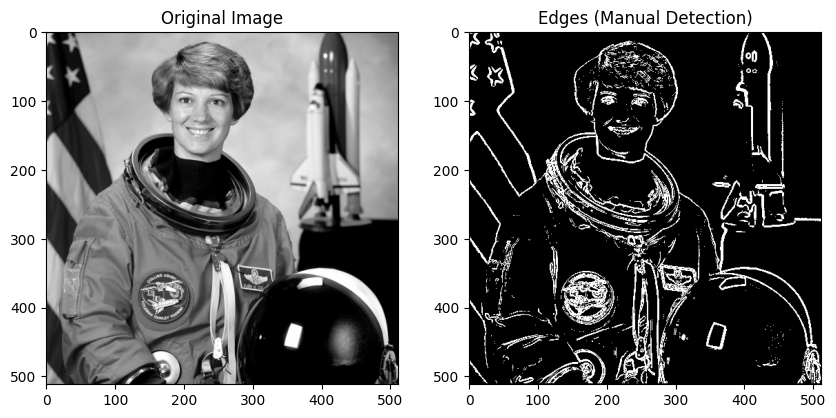

In [ ]:
# Manual edge detection by comparing neighboring pixels
# Get the dimensions of the image
height = astronaut_gray.shape[0]
width = astronaut_gray.shape[1]

# Create an empty array to store the edges
edges = np.zeros((height, width))

# Set a threshold - if the difference between pixels is greater than this, it's an edge
threshold = 0.15

# Loop through each pixel (except the edges of the image)
for row in range(1, height - 1):
    for col in range(1, width - 1):
        # Get the current pixel value
        current_pixel = astronaut_gray[row, col]
        
        # Get the neighboring pixel values
        left_pixel = astronaut_gray[row, col - 1]
        right_pixel = astronaut_gray[row, col + 1]
        top_pixel = astronaut_gray[row - 1, col]
        bottom_pixel = astronaut_gray[row + 1, col]
        
        # Calculate the differences
        horizontal_diff = abs(right_pixel - left_pixel)
        vertical_diff = abs(bottom_pixel - top_pixel)
        
        # If either difference is large enough, mark it as an edge
        if horizontal_diff > threshold or vertical_diff > threshold:
            edges[row, col] = 1  # Mark as edge (white)
        else:
            edges[row, col] = 0  # Not an edge (black)

# Display the results
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(astronaut_gray, cmap='gray')
axes[0].set_title("Original Image")
axes[1].imshow(edges, cmap='gray')
axes[1].set_title("Edges (Manual Detection)")
plt.show()

Edge detection with skimage

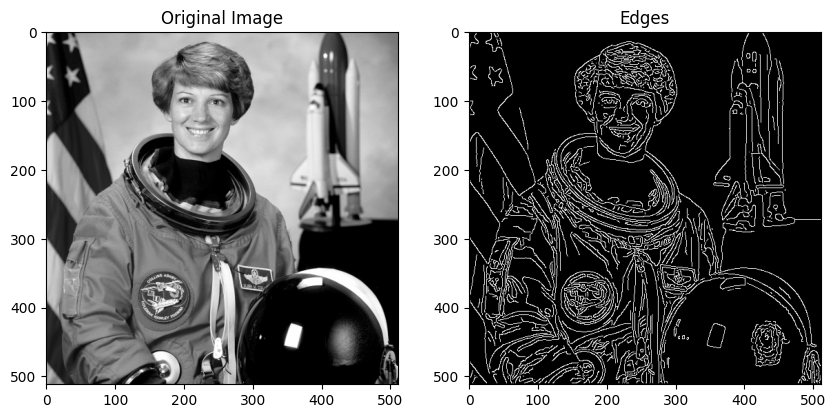

In [ ]:
edges = skimage.feature.canny(astronaut_gray)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(astronaut_gray, cmap='gray')
axes[0].set_title("Original Image")
axes[1].imshow(edges, cmap='gray')
axes[1].set_title("Edges")
plt.show()

Notice how the extracted edges maintain much of the details of the image in the foreground (e.g., the rocket ship and flag), but miss out details in the background (e.g., the wallpaper). Extracting the edges of an image can be useful for tasks like **object detection**, where we want to only focus on the most important parts of the image.

We can also consider the **edge density**: the proportion of pixels in the image that lie along an edge

#### More Features 📂

Just as with audio, there are many different kinds of spatial features we can extract from an image. For more details, check out [the documentation from `skimage`.](https://scikit-image.org/docs/0.25.x/api/skimage.feature.html)

### **Section 3. Summary**


---
## Conclusion

FILL OUT

